# Load and Explore Data

In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from nltk.stem.porter import PorterStemmer

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

RAW_CSV_DIR = "data/df.csv"
CLEAN_CSV_DIR = "data/cleaned_df.csv"

# load or create clean data
if os.path.exists(CLEAN_CSV_DIR):
    print(f"Found existing cleaned dataset at {CLEAN_CSV_DIR}. Loading instantly...")
    df = pd.read_csv(CLEAN_CSV_DIR)
    
else:
    print(f"Cleaned dataset not found. Loading raw data from {RAW_CSV_DIR}...")
    df = pd.read_csv(RAW_CSV_DIR)
    df = df.dropna(subset=['text'])
    
    ps = PorterStemmer()
    tqdm.pandas()
    
    def clean_spam_text(text):
        if not isinstance(text, str):
            return ""
        return ' '.join([ps.stem(word) for word in text.split()])

    # this take ~15 min
    df['cleaned_text'] = df['text'].progress_apply(clean_spam_text)
    
    df.to_csv(CLEAN_CSV_DIR, index=False)
    print("Saved successfully!")

df = df.dropna(subset=['cleaned_text', 'label'])
df = df[df['cleaned_text'].astype(str).str.strip() != '']

print(f"Dataset ready! Shape: {df.shape}")

Found existing cleaned dataset at data/cleaned_df.csv. Loading instantly...
Dataset ready! Shape: (365445, 3)


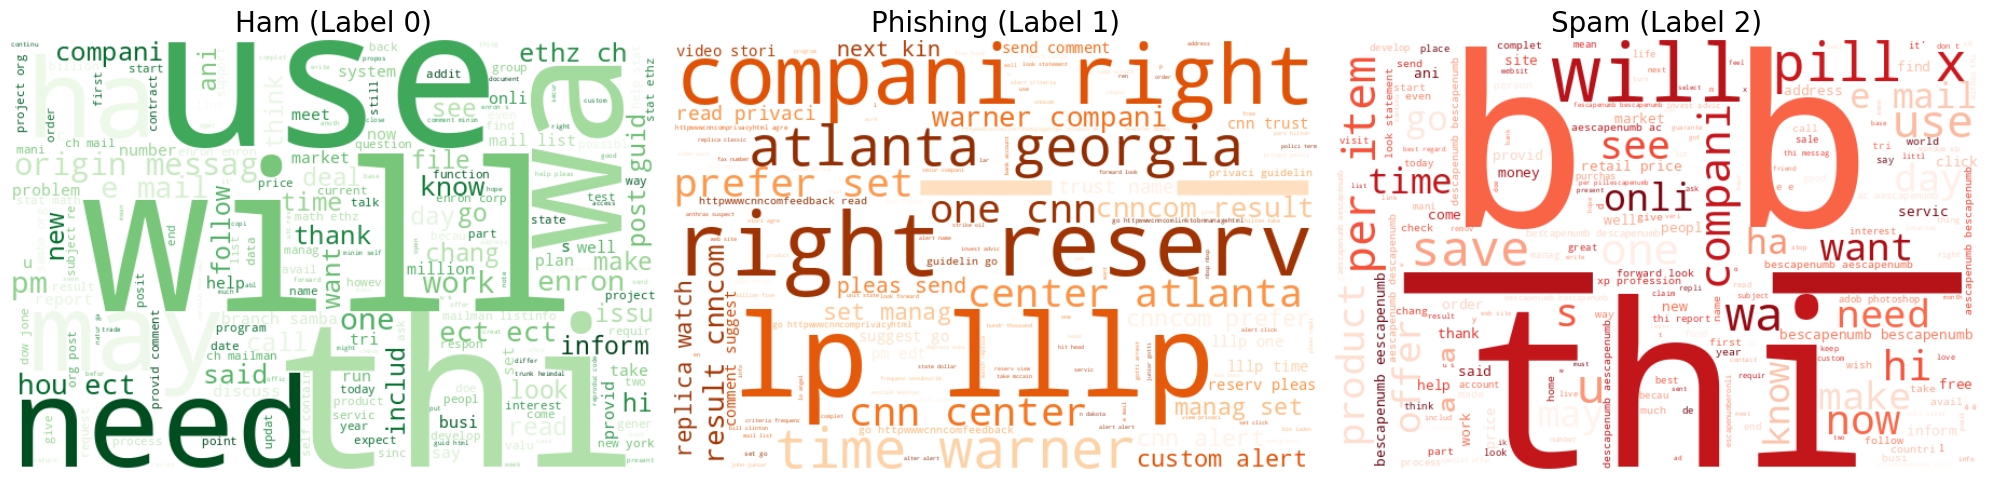

In [2]:

# custom stop words to ignore dataset artifacts and common email words
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'escapenumb', 'escapelong', 'escapenumber', 'escapenumberd','escapenumbermg','cescapenumb',
    'cabl', 'news', 'daili', 'fri', 'aug', 'wed', 'thu', 'mon', 'tue',
    'top', 'receiv', 'network', 'email' 
])

sample_size = 15000

# safely sample the text
df_ham = df[df['label'] == 0]
df_phish = df[df['label'] == 1]
df_spam = df[df['label'] == 2]

ham_sample = df_ham.sample(n=min(sample_size, len(df_ham)), random_state=42)
phish_sample = df_phish.sample(n=min(sample_size, len(df_phish)), random_state=42)
spam_sample = df_spam.sample(n=min(sample_size, len(df_spam)), random_state=42)

ham_text = " ".join(ham_sample['cleaned_text'].astype(str))
phish_text = " ".join(phish_sample['cleaned_text'].astype(str))
spam_text = " ".join(spam_sample['cleaned_text'].astype(str))

wc_ham = WordCloud(width=600, height=400, background_color='white', 
                   colormap='Greens', stopwords=custom_stopwords).generate(ham_text)
wc_phish = WordCloud(width=600, height=400, background_color='white', 
                     colormap='Oranges', stopwords=custom_stopwords).generate(phish_text)
wc_spam = WordCloud(width=600, height=400, background_color='white', 
                    colormap='Reds', stopwords=custom_stopwords).generate(spam_text)

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

axs[0].imshow(wc_ham, interpolation='bilinear')
axs[0].set_title('Ham (Label 0)', fontsize=20)
axs[0].axis('off')

axs[1].imshow(wc_phish, interpolation='bilinear')
axs[1].set_title('Phishing (Label 1)', fontsize=20)
axs[1].axis('off')

axs[2].imshow(wc_spam, interpolation='bilinear')
axs[2].set_title('Spam (Label 2)', fontsize=20)
axs[2].axis('off')

plt.tight_layout()
plt.show()

In [3]:
X = df['cleaned_text']
y = df['label'] # 0 -> ham, 1 -> phish, 2 -> spam

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

text_clf = Pipeline([
    ('vect', CountVectorizer(stop_words='english', min_df=2, max_df=0.7)), 
    ('clf', MultinomialNB())
])

print("Training Naive Bayes model...")
text_clf.fit(X_train, y_train)

predictions = text_clf.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, predictions))

Training Naive Bayes model...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     33709
           1       0.74      0.84      0.79      8626
           2       0.94      0.86      0.90     30754

    accuracy                           0.92     73089
   macro avg       0.87      0.90      0.88     73089
weighted avg       0.92      0.92      0.92     73089



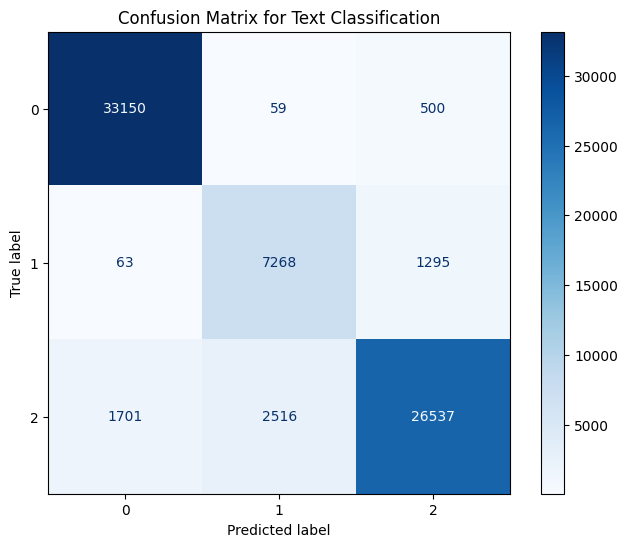

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

_, ax = plt.subplots(figsize=(8, 6))

cmd = ConfusionMatrixDisplay.from_estimator(
    text_clf, 
    X_test, 
    y_test, 
    display_labels=text_clf.classes_,
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title('Confusion Matrix for Text Classification')
plt.show()